In [1]:
!pwd

/Users/anshulchiranth/Desktop/Strike/Voice Experiments/Voice ID


In [2]:
from dotenv import load_dotenv
import os

load_dotenv()
api_key = os.getenv("AAI_API_KEY")

In [3]:
import assemblyai as aai
aai.settings.api_key = api_key

In [4]:
from pathlib import Path
import requests
import time

base_dir = Path.cwd()

transaction_dir = base_dir / "Unclipped Processed Transactions"

In [5]:
files = [f for f in transaction_dir.iterdir()
               if f.is_file() and not f.name.startswith(".")]

In [6]:
base_url = "https://api.assemblyai.com"

headers = {
"authorization": api_key
}

In [7]:
#Script to collect transcript with timestamps and operator/customer splits for julian files
transcripts = {}

for file in files:
    with open(file, "rb") as f:
        response = requests.post(base_url + "/v2/upload", headers=headers, data=f)
        if response.status_code != 200:
            print(f"Error: {response.status_code}, Response: {response.text}")
            response.raise_for_status()
        upload_json = response.json()
        audio_file = upload_json["upload_url"]


    data = {
    "audio_url": audio_file,
    "speech_models": ["universal-3-pro", "universal-2"],
    "language_detection": True,
    "speaker_labels": True,
    "speakers_expected": 2,
    "speech_understanding": {
        "request": {
            "speaker_identification": {
                "speaker_type": "name",
                "known_values": ["Customer", "Operator"]
                }
            }
        }
    }
    
    response = requests.post(base_url + "/v2/transcript", headers=headers, json=data)
    transcript_id = response.json()["id"]
    polling_endpoint = base_url + f"/v2/transcript/{transcript_id}"

    while True:
        transcript = requests.get(polling_endpoint, headers=headers).json()
        if transcript["status"] == "completed":
            break
        elif transcript["status"] == "error":
            raise RuntimeError(f"Transcription failed: {transcript['error']}")
        else:
            time.sleep(3)

    transcripts[file] = transcript

In [42]:
 len(transcripts)

82

In [43]:
len(intervals)

78

In [8]:
intervals = {}

for key, transcript in transcripts.items():
    specific_intervals = []
    for utterance in transcript["utterances"]:
        if utterance["speaker"] == "Operator":
            specific_intervals.append((utterance["start"], utterance["end"]))
    #Check that there are intervals identified for "Operator"
    if specific_intervals:
        intervals[key] = specific_intervals

In [9]:
from pathlib import Path
from pydub import AudioSegment

def extract_and_concat_segments(
    input_path: str | Path,
    segments_ms: list[tuple[int, int]],
    output_path: str | Path,
    output_format: str | None = None,  # e.g. "wav", "mp3"; if None, infer from output_path suffix
) -> Path:
    input_path = Path(input_path)
    output_path = Path(output_path)

    if output_format is None:
        output_format = output_path.suffix.lstrip(".").lower() or "wav"

    audio = AudioSegment.from_file(input_path)

    # Build output by concatenating slices
    out = AudioSegment.silent(duration=0, frame_rate=audio.frame_rate)

    for start_ms, end_ms in segments_ms:
        if start_ms < 0 or end_ms < 0:
            raise ValueError(f"Negative times not allowed: {(start_ms, end_ms)}")
        if end_ms <= start_ms:
            continue  # skip empty/invalid segment quietly

        start_ms = min(start_ms, len(audio))
        end_ms = min(end_ms, len(audio))
        if end_ms <= start_ms:
            continue

        out += audio[start_ms:end_ms]

    out.export(output_path, format=output_format)
    return output_path

# Example:
# segments = [(1200, 4500), (9000, 12500), (20000, 23000)]
# extract_and_concat_segments("input.wav", segments, "output.wav")


/opt/anaconda3/envs/voice_id_env/lib/python3.11/site-packages/pydub/utils.py:170: RuntimeWarning: Couldn't find ffmpeg or avconv - defaulting to ffmpeg, but may not work
  warn("Couldn't find ffmpeg or avconv - defaulting to ffmpeg, but may not work", RuntimeWarning)


In [10]:
output_dir = base_dir / "Concat Transactions"
output_dir.mkdir(parents = True, exist_ok = True)

In [11]:
file_name_counter = 1
for file, specific_intervals in intervals.items():
    operator_name = file.stem.split("_", 1)[0]
    extract_and_concat_segments(file, specific_intervals, output_dir / f"{operator_name}_concat_{file_name_counter}.wav")
    file_name_counter += 1


In [31]:
from pathlib import Path
base_dir = Path.cwd()

#Set up Various Directories
#Julian and George Raw Ground Truths Live in "Raw Ground Truths"
#They will go through processing and move to Processed Ground Truths, then prepare_audio_for_embedding() method and move to "To Be Embedded Ground Truths"
#Transaction Clips live in "Processed Transaction Clips". They only need to go through prepare_audio_for_embedding() method and move to "To Be Embedded Transactions


raw_truth_dir = base_dir / "Raw Ground Truths"
transaction_dir = base_dir / "Concat Transactions"

processed_dir = base_dir / "Processed Ground Truths"
output_dir = base_dir / "To Be Embedded Ground Truths"
to_embed_dir = base_dir / "To Be Embedded Transactions"

processed_dir.mkdir(parents=True, exist_ok=True)
output_dir.mkdir(parents = True, exist_ok = True)
to_embed_dir.mkdir(parents = True, exist_ok=True)

In [13]:
#Import Methods from utils.py
from utils import prepare_audio_for_embedding, decode_audio, preprocess_audio, save_audio

In [14]:
#Preprocessing Steps for Raw Ground Truths
#Pass through methods decode_audio(), preprocess_audio(), and save_audio()
#decode_audio() and preprocess_audio() combine to apply bandpass, AGC and limiter (in that order)
#save_audio() will save ground truths to "Processed Ground Truths"
from tqdm import tqdm

raw_input_files = [
    p for p in raw_truth_dir.iterdir()
    if p.is_file() and not p.name.startswith(".")
]
print(f"Found {len(raw_input_files)} raw input files.")

processed_audio_samples = []

for i, file_path in enumerate(raw_input_files):
    file_name = str(raw_input_files[i])[len(str(raw_truth_dir))+1:]
    audio, sr = decode_audio(file_path)
    processed_audio_sample = preprocess_audio(audio, sr)
    output_path = save_audio(audio, sr, processed_dir / f"Processed_{file_name}")
    print(f"Saved file to {output_path}")

Found 16 raw input files.
Saved file to /Users/anshulchiranth/Desktop/Strike/Voice Experiments/Voice ID/Processed Ground Truths/Processed_Oswaldo Ballesteros.wav
Saved file to /Users/anshulchiranth/Desktop/Strike/Voice Experiments/Voice ID/Processed Ground Truths/Processed_Edward Herrera.wav
Saved file to /Users/anshulchiranth/Desktop/Strike/Voice Experiments/Voice ID/Processed Ground Truths/Processed_Katie Carbajal-Mendoza.wav
Saved file to /Users/anshulchiranth/Desktop/Strike/Voice Experiments/Voice ID/Processed Ground Truths/Processed_Owen LaMontagne.wav
Saved file to /Users/anshulchiranth/Desktop/Strike/Voice Experiments/Voice ID/Processed Ground Truths/Processed_George Robbins.wav
Saved file to /Users/anshulchiranth/Desktop/Strike/Voice Experiments/Voice ID/Processed Ground Truths/Processed_Julian Carmona-Munoz.wav
Saved file to /Users/anshulchiranth/Desktop/Strike/Voice Experiments/Voice ID/Processed Ground Truths/Processed_Katherine Campos.wav
Saved file to /Users/anshulchiranth

In [15]:
#Get Preprocessed Ground Truths Ready for Embedding
#prepare_audio_for_embedding() method will set frame rate of the .wav to 16kHz
processed_files = [f for f in processed_dir.rglob("*") if f.is_file() and not f.name.startswith(".")]

print(f"Found {len(processed_files)} audio files")

for processed_file in tqdm(processed_files):
    processed_path = prepare_audio_for_embedding(processed_file, output_dir)

Found 16 audio files


100%|██████████| 16/16 [00:00<00:00, 718.49it/s]


In [16]:
#Get Preprocessed Transaction Clips Ready for Embedding
processed_files = [f for f in transaction_dir.rglob("*") if f.is_file() and not f.name.startswith(".")]

print(f"Found {len(processed_files)} audio files")

for processed_file in tqdm(processed_files):
    processed_path = prepare_audio_for_embedding(processed_file, to_embed_dir)

Found 78 audio files


100%|██████████| 78/78 [00:00<00:00, 1143.07it/s]


In [17]:
#Standard Code to set up TitaNet
#Set to eval() mode for future embedding
import torch
import nemo.collections.asr as nemo_asr

device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print("device:", device)

# Pretrained TitaNet Large speaker verification model
speaker_model = nemo_asr.models.EncDecSpeakerLabelModel.from_pretrained(
    model_name="nvidia/speakerverification_en_titanet_large"
).to(device)

speaker_model.eval()

/opt/anaconda3/envs/voice_id_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO:numexpr.utils:NumExpr defaulting to 12 threads.
[NeMo W 2026-02-24 17:51:15 nemo_logging:405] Megatron num_microbatches_calculator not found, using Apex version.
W0224 17:51:15.557000 24941 site-packages/torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.
INFO:nv_one_logger.exporter.export_config_manager:Final configuration contains 0 exporter(s)
[NeMo W 2026-02-24 17:51:16 nemo_logging:405] If you intend to do training or fine-tuning, please call the ModelPT.setup_training_data() method and provide a valid configuration file to setup the train data loader.
    Train config : 
    manifest_filepath: /manifests/combined_fisher_swbd_voxceleb12_libris

device: mps
[NeMo I 2026-02-24 17:51:16 nemo_logging:393] PADDING: 16
[NeMo I 2026-02-24 17:51:17 nemo_logging:393] Model EncDecSpeakerLabelModel was successfully restored from /Users/anshulchiranth/.cache/huggingface/hub/models--nvidia--speakerverification_en_titanet_large/snapshots/0dc382f40121a5fbd34db10a2bb04d826c2be6a8/speakerverification_en_titanet_large.nemo.


EncDecSpeakerLabelModel(
  (loss): AngularSoftmaxLoss()
  (eval_loss): AngularSoftmaxLoss()
  (_accuracy): TopKClassificationAccuracy()
  (preprocessor): AudioToMelSpectrogramPreprocessor(
    (featurizer): FilterbankFeatures()
  )
  (encoder): ConvASREncoder(
    (encoder): Sequential(
      (0): JasperBlock(
        (mconv): ModuleList(
          (0): MaskedConv1d(
            (conv): Conv1d(80, 80, kernel_size=(3,), stride=(1,), padding=(1,), groups=80, bias=False)
          )
          (1): MaskedConv1d(
            (conv): Conv1d(80, 1024, kernel_size=(1,), stride=(1,), bias=False)
          )
          (2): BatchNorm1d(1024, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
          (3): SqueezeExcite(
            (fc): Sequential(
              (0): Linear(in_features=1024, out_features=128, bias=False)
              (1): ReLU(inplace=True)
              (2): Linear(in_features=128, out_features=1024, bias=False)
            )
            (gap): AdaptiveAvgPool1d(

In [32]:
#Process for Embedding Ground Truth Embeddings
#They are saved to Ground Truth Embeddings/

emb_dir = base_dir / "Ground Truth Embeddings"
emb_dir.mkdir(parents = True, exist_ok = True)


wav_files = sorted([p for p in output_dir.rglob("*.wav")])
print("WAV files found:", len(wav_files))
print("example:", wav_files[0] if wav_files else "None")

import numpy as np
import pandas as pd
from tqdm import tqdm

rows = []
all_embs = {}  # {relative_path: embedding_vector}

with torch.no_grad():
    for wav_path in tqdm(wav_files):
        # NeMo provides get_embedding(path_to_wav) for speaker embeddings :contentReference[oaicite:3]{index=3}
        emb = speaker_model.get_embedding(str(wav_path))

        # Normalize output type -> 1D numpy array
        if isinstance(emb, torch.Tensor):
            emb_np = emb.detach().cpu().numpy()
        else:
            emb_np = np.asarray(emb)

        emb_np = np.squeeze(emb_np)  # ensure shape (D,)

        # Save one embedding per file
        rel = wav_path.relative_to(output_dir)
        out_path = emb_dir / rel.with_suffix(".npy")
        out_path.parent.mkdir(parents=True, exist_ok=True)
        np.save(out_path, emb_np)

        rows.append({
            "wav_path": str(wav_path),
            "embedding_path": str(out_path),
            "dim": int(emb_np.shape[0]),
        })
        all_embs[str(rel)] = emb_np

df = pd.DataFrame(rows)
df.to_csv(emb_dir / "index.csv", index=False)

# Also save a single archive for easy loading later
np.savez_compressed(emb_dir / "embeddings.npz", **all_embs)

print("Saved embeddings to:", emb_dir)
print(df.head())

WAV files found: 16
example: /Users/anshulchiranth/Desktop/Strike/Voice Experiments/Voice ID/To Be Embedded Ground Truths/Processed_Brianna Leach-Richardson_converted.wav


100%|██████████| 16/16 [00:02<00:00,  7.99it/s]

Saved embeddings to: /Users/anshulchiranth/Desktop/Strike/Voice Experiments/Voice ID/Ground Truth Embeddings
                                            wav_path  \
0  /Users/anshulchiranth/Desktop/Strike/Voice Exp...   
1  /Users/anshulchiranth/Desktop/Strike/Voice Exp...   
2  /Users/anshulchiranth/Desktop/Strike/Voice Exp...   
3  /Users/anshulchiranth/Desktop/Strike/Voice Exp...   
4  /Users/anshulchiranth/Desktop/Strike/Voice Exp...   

                                      embedding_path  dim  
0  /Users/anshulchiranth/Desktop/Strike/Voice Exp...  192  
1  /Users/anshulchiranth/Desktop/Strike/Voice Exp...  192  
2  /Users/anshulchiranth/Desktop/Strike/Voice Exp...  192  
3  /Users/anshulchiranth/Desktop/Strike/Voice Exp...  192  
4  /Users/anshulchiranth/Desktop/Strike/Voice Exp...  192  


In [21]:
#Process for Embedding Transaction
#Saved to Transaction Embeddings/
emb_dir = base_dir / "Transaction Embeddings"
emb_dir.mkdir(parents = True, exist_ok = True)

wav_files = sorted([p for p in to_embed_dir.rglob("*.wav")])
print("WAV files found:", len(wav_files))
print("example:", wav_files[0] if wav_files else "None")

import numpy as np
import pandas as pd
from tqdm import tqdm

rows = []
all_embs = {}  # {relative_path: embedding_vector}

with torch.no_grad():
    for wav_path in tqdm(wav_files):
        # NeMo provides get_embedding(path_to_wav) for speaker embeddings :contentReference[oaicite:3]{index=3}
        emb = speaker_model.get_embedding(str(wav_path))

        # Normalize output type -> 1D numpy array
        if isinstance(emb, torch.Tensor):
            emb_np = emb.detach().cpu().numpy()
        else:
            emb_np = np.asarray(emb)

        emb_np = np.squeeze(emb_np)  # ensure shape (D,)

        # Save one embedding per file
        rel = wav_path.relative_to(to_embed_dir)
        out_path = emb_dir / rel.with_suffix(".npy")
        out_path.parent.mkdir(parents=True, exist_ok=True)
        np.save(out_path, emb_np)

        rows.append({
            "wav_path": str(wav_path),
            "embedding_path": str(out_path),
            "dim": int(emb_np.shape[0]),
        })
        all_embs[str(rel)] = emb_np

df = pd.DataFrame(rows)
df.to_csv(emb_dir / "index.csv", index=False)

# Also save a single archive for easy loading later
np.savez_compressed(emb_dir / "embeddings.npz", **all_embs)

print("Saved embeddings to:", emb_dir)
print(df.head())

WAV files found: 78
example: /Users/anshulchiranth/Desktop/Strike/Voice Experiments/Voice ID/To Be Embedded Transactions/Edward_concat_14_converted.wav


100%|██████████| 78/78 [00:12<00:00,  6.42it/s]

Saved embeddings to: /Users/anshulchiranth/Desktop/Strike/Voice Experiments/Voice ID/Transaction Embeddings
                                            wav_path  \
0  /Users/anshulchiranth/Desktop/Strike/Voice Exp...   
1  /Users/anshulchiranth/Desktop/Strike/Voice Exp...   
2  /Users/anshulchiranth/Desktop/Strike/Voice Exp...   
3  /Users/anshulchiranth/Desktop/Strike/Voice Exp...   
4  /Users/anshulchiranth/Desktop/Strike/Voice Exp...   

                                      embedding_path  dim  
0  /Users/anshulchiranth/Desktop/Strike/Voice Exp...  192  
1  /Users/anshulchiranth/Desktop/Strike/Voice Exp...  192  
2  /Users/anshulchiranth/Desktop/Strike/Voice Exp...  192  
3  /Users/anshulchiranth/Desktop/Strike/Voice Exp...  192  
4  /Users/anshulchiranth/Desktop/Strike/Voice Exp...  192  


In [36]:
from pathlib import Path
import numpy as np
import pandas as pd

# --- paths (relative to current working directory) ---
tx_dir = Path.cwd() / "Transaction Embeddings"
gt_dir = Path.cwd() / "Ground Truth Embeddings"

# --- collect only .npy files, ignore everything else ---
tx_files = sorted([p for p in tx_dir.iterdir() if p.is_file() and p.suffix == ".npy"])
gt_files = sorted([p for p in gt_dir.iterdir() if p.is_file() and p.suffix == ".npy"])

if not tx_files:
    raise FileNotFoundError(f"No .npy files found in: {tx_dir}")
if not gt_files:
    raise FileNotFoundError(f"No .npy files found in: {gt_dir}")

# --- load helpers ---
def load_vec_192(path: Path) -> np.ndarray:
    """Load an embedding and return shape (192,) float32."""
    v = np.load(path)
    v = np.asarray(v, dtype=np.float32).reshape(-1)  # flatten any (1,192) or (192,1) etc.
    if v.shape[0] != 192:
        raise ValueError(f"{path.name}: expected 192 values, got {v.shape[0]} with original shape {np.load(path).shape}")
    return v

# --- load all embeddings ---
tx_mat = np.stack([load_vec_192(p) for p in tx_files], axis=0)   # (N, 192)
gt_mat = np.stack([load_vec_192(p) for p in gt_files], axis=0)   # (M, 192)

# --- cosine similarity (manual; no sklearn needed) ---
# sim = (A @ B.T) / (||A|| * ||B||)
tx_norm = np.linalg.norm(tx_mat, axis=1, keepdims=True)          # (N, 1)
gt_norm = np.linalg.norm(gt_mat, axis=1, keepdims=True)          # (M, 1)

# avoid divide-by-zero just in case
tx_norm = np.clip(tx_norm, 1e-12, None)
gt_norm = np.clip(gt_norm, 1e-12, None)

sim = (tx_mat @ gt_mat.T) / (tx_norm * gt_norm.T)               # (N, M)

# --- build dataframe ---
row_names = [p.stem for p in tx_files]
col_names = [p.stem for p in gt_files]

df = pd.DataFrame(sim, index=row_names, columns=col_names).round(5)

# mapping from full column name → operator name

operator_map = {
    'Processed_Brianna Leach-Richardson_converted': "Brianna",
       'Processed_Edward Herrera_converted': "Edward",
       'Processed_George Robbins_converted': "George",
       'Processed_Gunnar Mckinnon_converted': "Gunnar", 'Processed_Jake Wohl_converted': "Jake",
       'Processed_Julian Carmona-Munoz_converted': "Julian",
       'Processed_Katherine Campos_converted': "Katherine",
       'Processed_Katie Carbajal-Mendoza_converted': "Katie",
       'Processed_Kayla Devito_converted': "Kayla",
       'Processed_Kennith Newkirk_converted': "Kennith",
       'Processed_Kyleigh Harp_converted': "Kyleigh", 'Processed_Maria Mendoza_converted': "Maria",
       'Processed_Olivia Jensen_converted': "Olivia",
       'Processed_Oswaldo Ballesteros_converted': "Oswaldo",
       'Processed_Owen LaMontagne_converted': "Owen",
       'Processed_Shaniyah Smith_converted': "Shaniyah"
    
}



# Get column name of max similarity per row
max_cols = df.idxmax(axis=1)



# Map to clean operator names
df["Recognized Operator"] = max_cols.map(operator_map)

# Convert index to a Series so we can use .str methods
index_series = df.index.to_series()



df["Ground Truth Operator"] = None  # initialize column

df.loc[index_series.str.contains("George", case=False, na=False),
       "Ground Truth Operator"] = "George"

df.loc[index_series.str.contains("Julian", case=False, na=False),
       "Ground Truth Operator"] = "Julian"

df.loc[index_series.str.contains("Jake", case=False, na=False),
       "Ground Truth Operator"] = "Jake"

df.loc[index_series.str.contains("Edward", case=False, na=False),
       "Ground Truth Operator"] = "Edward"

df.loc[index_series.str.contains("Gunnar", case=False, na=False),
       "Ground Truth Operator"] = "Gunnar"

df.loc[index_series.str.contains("Katherine", case=False, na=False),
       "Ground Truth Operator"] = "Katherine"

df.loc[index_series.str.contains("Kayla", case=False, na=False),
       "Ground Truth Operator"] = "Kayla"

df.loc[index_series.str.contains("Kennith", case=False, na=False),
       "Ground Truth Operator"] = "Kennith"

df.loc[index_series.str.contains("Maria", case=False, na=False),
       "Ground Truth Operator"] = "Maria"

df.loc[index_series.str.contains("Travis", case=False, na=False),
       "Ground Truth Operator"] = "Travis"

df.loc[index_series.str.contains("Oswaldo", case=False, na=False),
       "Ground Truth Operator"] = "Oswaldo"

df["Correct Identification"] = (
    df["Recognized Operator"] == df["Ground Truth Operator"]
)


In [37]:
df

,Processed_Brianna Leach-Richardson_converted,Processed_Edward Herrera_converted,Processed_George Robbins_converted,Processed_Gunnar Mckinnon_converted,Processed_Jake Wohl_converted,Processed_Julian Carmona-Munoz_converted,Processed_Katherine Campos_converted,Processed_Katie Carbajal-Mendoza_converted,Processed_Kayla Devito_converted,Processed_Kennith Newkirk_converted,Processed_Kyleigh Harp_converted,Processed_Maria Mendoza_converted,Processed_Olivia Jensen_converted,Processed_Oswaldo Ballesteros_converted,Processed_Owen LaMontagne_converted,Processed_Shaniyah Smith_converted,Recognized Operator,Ground Truth Operator,Correct Identification
Edward_concat_14_converted,0.07071,0.32575,0.05651,-0.07439,0.16646,0.27638,0.01519,0.06266,0.06664,0.08039,0.10594,0.10830,0.11348,0.00210,0.00861,0.08526,Edward,Edward,True
Edward_concat_3_converted,0.21631,0.78967,0.07821,0.00365,0.23484,0.36659,0.00183,0.11971,-0.01674,0.12592,0.10872,0.19676,0.14853,0.05178,0.00074,0.21817,Edward,Edward,True
Edward_concat_40_converted,0.18037,0.76208,0.05906,0.02434,0.24863,0.41965,-0.00970,0.08471,-0.04329,0.08482,0.12248,0.21663,0.12013,-0.02356,0.01432,0.20309,Edward,Edward,True
George_concat_46_converted,0.15037,0.17455,0.81033,0.09019,-0.00036,0.11942,0.07299,0.03370,0.05393,-0.02705,0.06356,0.10268,0.14932,-0.02701,0.18848,0.05282,George,George,True
George_concat_4_converted,0.12207,0.21370,0.28106,0.17297,0.22347,0.38649,0.18625,0.15087,0.10119,0.11690,0.20749,0.20090,0.19908,0.14967,0.55353,0.14709,Owen,George,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
julian_concat_19_converted,0.01368,0.25088,0.15550,0.08043,0.22530,0.67263,0.18439,0.12736,-0.03778,0.09939,0.11536,0.13085,0.06463,0.18690,0.25973,0.14081,Julian,Julian,True
julian_concat_1_converted,0.03642,0.22462,0.02288,0.09383,0.27480,0.61650,0.16255,0.09888,-0.01605,0.06200,0.16878,0.12507,0.07054,0.20946,0.19739,0.15624,Julian,Julian,True
julian_concat_2_converted,0.08455,0.36684,-0.00691,0.06771,0.37104,0.79566,0.18720,0.14494,0.05199,0.15419,0.14649,0.16688,0.11880,0.28975,0.21982,0.12493,Julian,Julian,True
julian_concat_7_converted,0.08565,0.31672,0.12476,0.11139,0.33070,0.79034,0.18951,0.12747,-0.02528,0.07176,0.10202,0.11979,0.06869,0.26246,0.23670,0.16908,Julian,Julian,True


In [38]:
df[df["Correct Identification"] == False]

,Processed_Brianna Leach-Richardson_converted,Processed_Edward Herrera_converted,Processed_George Robbins_converted,Processed_Gunnar Mckinnon_converted,Processed_Jake Wohl_converted,Processed_Julian Carmona-Munoz_converted,Processed_Katherine Campos_converted,Processed_Katie Carbajal-Mendoza_converted,Processed_Kayla Devito_converted,Processed_Kennith Newkirk_converted,Processed_Kyleigh Harp_converted,Processed_Maria Mendoza_converted,Processed_Olivia Jensen_converted,Processed_Oswaldo Ballesteros_converted,Processed_Owen LaMontagne_converted,Processed_Shaniyah Smith_converted,Recognized Operator,Ground Truth Operator,Correct Identification
George_concat_4_converted,0.12207,0.21370,0.28106,0.17297,0.22347,0.38649,0.18625,0.15087,0.10119,0.11690,0.20749,0.20090,0.19908,0.14967,0.55353,0.14709,Owen,George,False
George_concat_6_converted,0.11556,0.16754,0.16839,0.09810,0.18355,0.21762,0.07300,0.16435,0.10784,0.25434,0.18257,0.18812,0.19033,0.11395,0.60706,0.16101,Owen,George,False
George_concat_73_converted,0.06746,0.09515,0.21868,0.05442,0.11919,0.18403,0.13184,0.12636,0.16528,0.20826,0.23549,0.19949,0.20633,0.04283,0.60689,0.11076,Owen,George,False
George_concat_78_converted,0.10871,0.07853,0.22392,0.07199,0.17509,0.17071,0.15686,0.17346,0.16220,0.26827,0.22609,0.25238,0.23790,0.08854,0.65726,0.18861,Owen,George,False
Maria_concat_18_converted,0.13269,0.09480,0.01923,0.03749,0.08755,0.06352,0.25073,0.16172,0.19297,0.14391,0.54444,0.40771,0.30995,0.03209,0.11259,0.40866,Kyleigh,Maria,False
Maria_concat_54_converted,0.10468,-0.06706,0.05332,0.19193,-0.05920,-0.05826,0.07348,0.10899,0.66559,-0.08332,0.15440,0.04856,0.14679,-0.01536,0.07418,0.13969,Kayla,Maria,False
Travis_concat_20_converted,0.08559,-0.03103,0.20191,0.18032,0.02516,0.19024,0.31136,0.10811,0.07297,0.08372,0.19020,0.14775,0.19036,0.14143,0.28335,0.17088,Katherine,Travis,False
Travis_concat_75_converted,0.07065,-0.03703,0.12766,0.23067,0.09033,0.10830,0.25530,0.08336,0.01724,0.09814,0.08578,0.10638,0.12480,0.21194,0.36082,0.07177,Owen,Travis,False


In [44]:
print(f"Accuracy: {len(df[df['Correct Identification'] == True]) * 100 / len(transcripts)}")

Accuracy: 85.36585365853658


In [61]:
formatted_transcripts = {}

for key, transcript in transcripts.items():
    statements = []
    for utterance in transcript["utterances"]:
        statement = f"{utterance['speaker']}: {utterance['text']}"
        statements.append(statement)
    result = "\n".join(statements)
    formatted_transcripts[key] = result

In [73]:
#Add transcripts to each row, can drop cosine similarity values
updated_df = df.copy()
updated_df.index = updated_df.index.str.replace(r"_concat_\d+_converted$", "", regex=True)

updated_df.index = updated_df.index.astype(str) + ".wav"
updated_df = updated_df[["Recognized Operator"]]
test_file_path = Path("/Users/anshulchiranth/Desktop/Strike/Voice Experiments/test_output")
updated_df["file_path"] = updated_df.index.map(lambda x: test_file_path / x)
updated_df["transcript"] = updated_df["file_path"].map(formatted_transcripts)
updated_df["transaction_id"] = updated_df.index.str.replace(r"\.wav$", "", regex=True)
updated_df["file_name"] = updated_df.index
updated_df.drop(["file_path"], inplace = True, axis = 1)
updated_df

,Recognized Operator,transcript,transaction_id,file_name
018d4e9a-a84d-406e-8286-7d9872acd890.wav,Maria,Operator: It's a wonderful day at Dairy Queen....,018d4e9a-a84d-406e-8286-7d9872acd890,018d4e9a-a84d-406e-8286-7d9872acd890.wav
0477a455-2a7b-49dc-977e-3e9766cb69df.wav,Maria,"Operator: It's a wonderful day. Dairy Queen, w...",0477a455-2a7b-49dc-977e-3e9766cb69df,0477a455-2a7b-49dc-977e-3e9766cb69df.wav
05543850-772f-4ee4-a006-27946e28cfdc.wav,Julian,Operator: Thank you for choosing Dairy Queen. ...,05543850-772f-4ee4-a006-27946e28cfdc,05543850-772f-4ee4-a006-27946e28cfdc.wav
05c7ac83-c9f5-47e8-a88b-4c797cbbf4b0.wav,Katie,Operator: It's a wonderful day at Dairy Queen....,05c7ac83-c9f5-47e8-a88b-4c797cbbf4b0,05c7ac83-c9f5-47e8-a88b-4c797cbbf4b0.wav
06515c65-8a23-4076-a245-d1381f3452d4.wav,Owen,"Operator: It's a wonderful day, Derek. When wi...",06515c65-8a23-4076-a245-d1381f3452d4,06515c65-8a23-4076-a245-d1381f3452d4.wav
...,...,...,...,...
f8ea7008-a88a-4e14-b0a8-3964920db7ba.wav,Maria,"Operator: All right, what can I get for you?\n...",f8ea7008-a88a-4e14-b0a8-3964920db7ba,f8ea7008-a88a-4e14-b0a8-3964920db7ba.wav
fa29bb14-e411-46f9-b36a-9f425a08609c.wav,Maria,"Operator: It's a wonderful day. Dairy Queen, a...",fa29bb14-e411-46f9-b36a-9f425a08609c,fa29bb14-e411-46f9-b36a-9f425a08609c.wav
faa0ae98-dad6-47e1-a01c-535338aeb17f.wav,Owen,Operator: It's a wonderful day there. Can we b...,faa0ae98-dad6-47e1-a01c-535338aeb17f,faa0ae98-dad6-47e1-a01c-535338aeb17f.wav
fc5abfb7-9ff8-4d72-ac8d-ee655394772c.wav,Edward,Operator: It's a wonderful day out there. Are ...,fc5abfb7-9ff8-4d72-ac8d-ee655394772c,fc5abfb7-9ff8-4d72-ac8d-ee655394772c.wav


In [75]:
updated_df.to_csv("AAI_test_results.csv", index = False)

In [76]:
len(intervals)

225

In [77]:
len(transcripts)

241

Explained variance ratio: [0.13906273 0.10311455]


/var/folders/q2/pyrq5k_s7gz_4v527qy_7lcc0000gn/T/ipykernel_83587/829192117.py:23: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_2d[i,0], X_2d[i,1], label=label.split("/")[-1], s=100, cmap = "tab20")


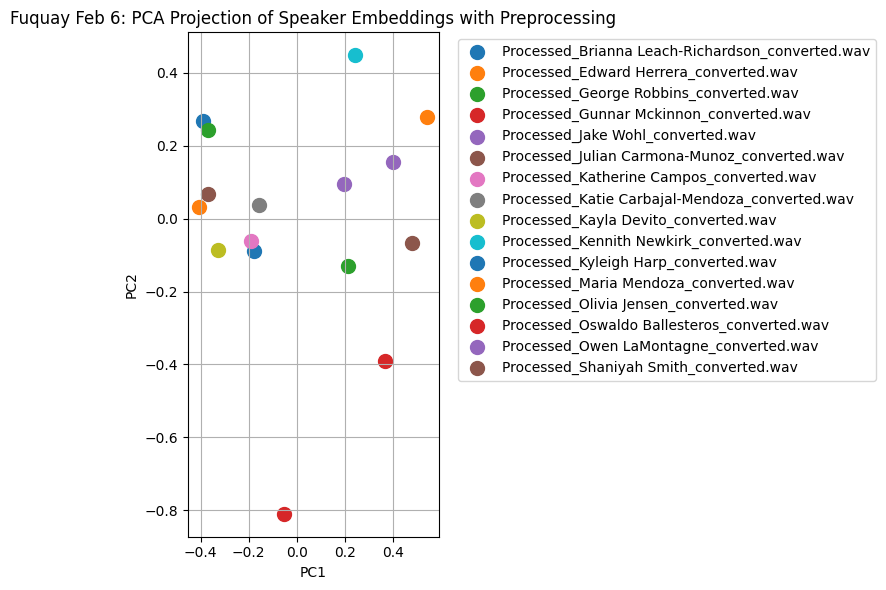

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Load embeddings
npz = np.load("Ground Truth Embeddings/embeddings.npz")
keys = list(npz.keys())
X = np.stack([npz[k] for k in keys])

# Optional: normalize for cosine geometry (recommended)
X = X / np.linalg.norm(X, axis=1, keepdims=True)

# PCA
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

print("Explained variance ratio:", pca.explained_variance_ratio_)

plt.figure(figsize=(8,6))

for i, label in enumerate(keys):
    plt.scatter(X_2d[i,0], X_2d[i,1], label=label.split("/")[-1], s=100, cmap = "tab20")

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.title("Fuquay Feb 6: PCA Projection of Speaker Embeddings with Preprocessing")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.tight_layout()
plt.show()
#plt.savefig("Lakewood Feb 6: PCA Projection of Speaker Embeddings with Preprocessing.png")


In [81]:
george = np.load("Ground Truth Embeddings/Processed_George Robbins_converted.npy")
owen = np.load("Ground Truth Embeddings/Processed_Owen LaMontagne_converted.npy")

In [82]:
import numpy as np

def cosine(a, b, eps=1e-9):
    a = a / (np.linalg.norm(a) + eps)
    b = b / (np.linalg.norm(b) + eps)
    return float(np.dot(a, b))

cosine(george, owen)

0.13644357025623322

Explained variance ratio: [0.13906273 0.10311455]


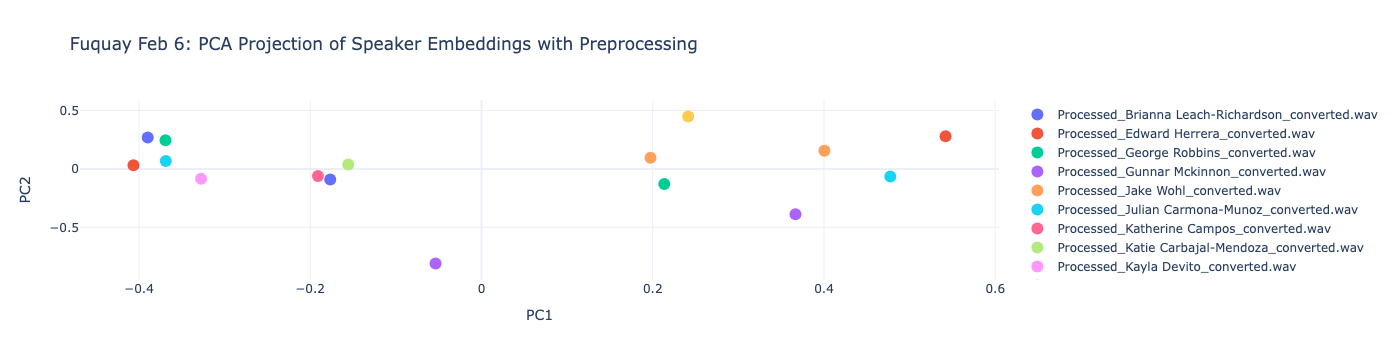

In [2]:
import numpy as np
from sklearn.decomposition import PCA
import pandas as pd
import plotly.express as px

# Load embeddings
npz = np.load("Ground Truth Embeddings/embeddings.npz")
keys = list(npz.keys())
X = np.stack([npz[k] for k in keys])

# Optional: normalize for cosine geometry (recommended)
X = X / np.linalg.norm(X, axis=1, keepdims=True)

# PCA
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

print("Explained variance ratio:", pca.explained_variance_ratio_)

# Labels (match your matplotlib legend logic)
labels = [k.split("/")[-1] for k in keys]

# Put into a DataFrame for Plotly
df = pd.DataFrame({
    "PC1": X_2d[:, 0],
    "PC2": X_2d[:, 1],
    "label": labels,
    "key": keys,  # full key/path for hover if you want it
})

fig = px.scatter(
    df,
    x="PC1",
    y="PC2",
    color="label",                 # different colors per point/label
    hover_name="label",            # big bold title in hover
    hover_data={"key": True, "PC1": ":.4f", "PC2": ":.4f", "label": False},
    title="Fuquay Feb 6: PCA Projection of Speaker Embeddings with Preprocessing",
)

fig.update_traces(marker=dict(size=12))
fig.update_layout(
    xaxis_title="PC1",
    yaxis_title="PC2",
    legend_title_text="",
    template="plotly_white",
)

fig.show()

Explained variance ratio: [0.13924564 0.10326908]


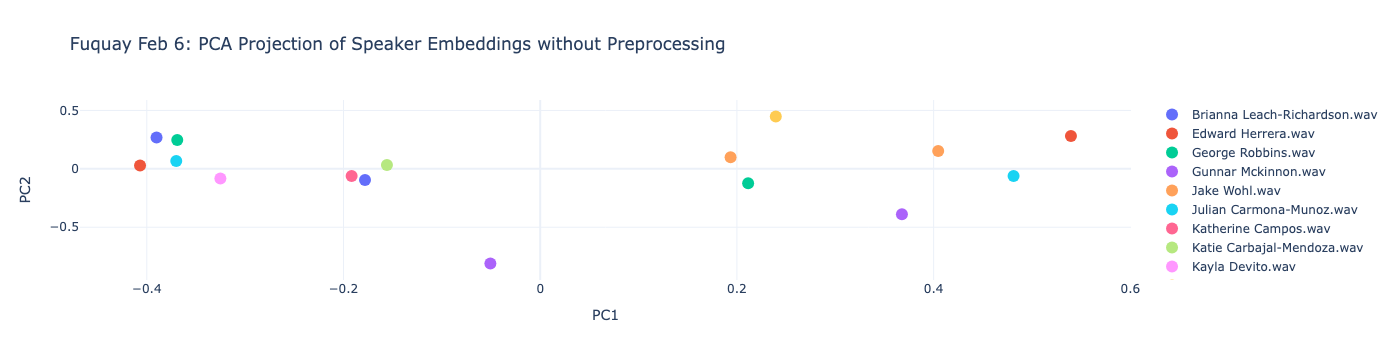

In [8]:
import numpy as np
from sklearn.decomposition import PCA
import pandas as pd
import plotly.express as px

# Load embeddings
npz = np.load("Unprocessed Ground Truth Embeddings/embeddings.npz")
keys = list(npz.keys())
X = np.stack([npz[k] for k in keys])

# Optional: normalize for cosine geometry (recommended)
X = X / np.linalg.norm(X, axis=1, keepdims=True)

# PCA
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

print("Explained variance ratio:", pca.explained_variance_ratio_)

# Labels (match your matplotlib legend logic)
labels = [k.split("/")[-1] for k in keys]

# Put into a DataFrame for Plotly
df = pd.DataFrame({
    "PC1": X_2d[:, 0],
    "PC2": X_2d[:, 1],
    "label": labels,
    "key": keys,  # full key/path for hover if you want it
})

fig = px.scatter(
    df,
    x="PC1",
    y="PC2",
    color="label",                 # different colors per point/label
    hover_name="label",            # big bold title in hover
    hover_data={"key": True, "PC1": ":.4f", "PC2": ":.4f", "label": False},
    title="Fuquay Feb 6: PCA Projection of Speaker Embeddings without Preprocessing",
)

fig.update_traces(marker=dict(size=12))
fig.update_layout(
    xaxis_title="PC1",
    yaxis_title="PC2",
    legend_title_text="",
    template="plotly_white",
)

fig.show()

In [47]:
from pathlib import Path
from mutagen import File

# Change this to your folder path
folder_path = transaction_dir

audio_extensions = {".mp3", ".wav", ".flac", ".m4a", ".aac", ".ogg"}

total_seconds = 0

# rglob searches recursively
for file_path in folder_path.rglob("*"):
    if file_path.suffix.lower() in audio_extensions:
        audio = File(file_path)
        if audio is not None and audio.info is not None:
            total_seconds += audio.info.length

# Convert seconds to h:m:s
hours = int(total_seconds // 3600)
minutes = int((total_seconds % 3600) // 60)
seconds = int(total_seconds % 60)

print(f"Total duration: {hours}h {minutes}m {seconds}s")

Total duration: 0h 18m 15s
